<center>
<a href="https://nxv.fr"> <img src="https://nxv.fr/img/logo-NXV-fondtransparent.png" width="400"> </a>
</center>

# 🧠 One neuron for regression! 
In this notebook, we will create an artificial neuron, able to calculate linear regression from data samples. 
Let's first import modules:

In [ ]:
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import Adam
from sklearn.model_selection import train_test_split

import numpy as np

## 📈 Dataset
We now build the dataset with noisy sample points, according to the underlying equation $y = m.x+b$. The parameters can be changed to see the learning adaptability of the model

In [ ]:
# Generate data points
X = np.random.randn(500, 1)
m = 2
b = 3
noise = 0.5
y = m * X[:, 0] + b + np.random.normal(scale=noise, size=500)

# Reshape and split the data
y = y.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)

Plot the data: 

In [ ]:
plt.scatter(X_train, y_train, c='k', s=2)
plt.show()

The inherited `RegressionData` class will help us handling the dataset for Pytorch data loader:

In [ ]:
class RegressionData(Dataset):
  def __init__(self, X: np.ndarray, y: np.ndarray) -> None:
    self.X = torch.from_numpy(X.astype(np.float32))
    self.y = torch.from_numpy(y.astype(np.float32))
    self.len = self.X.shape[0]
  def __getitem__(self, index: int) -> tuple:
    return self.X[index], self.y[index]
  def __len__(self) -> int:
    return self.len

In [ ]:
train_data = RegressionData(X_train, y_train)
train_loader = DataLoader(train_data, batch_size=50, shuffle=True)

## 🛠️ The model 
Let's build the one-neuron model as illustrated here:

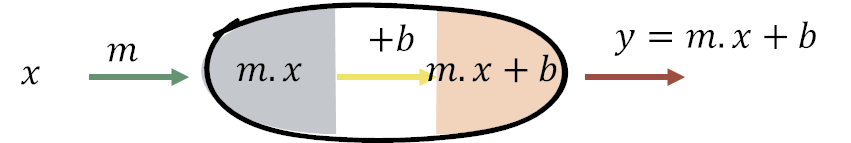


In [ ]:
layers = [
    nn.Linear(1, 1),
]
model = nn.Sequential(*layers)
print(model)
model = torch.compile(model)
loss_function = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=0.1)

We run the optimization process as usual

In [ ]:
loss = 0
epochs = 10
for epoch in range(epochs):
    loss = 0
    for i, (x, y) in enumerate(train_loader):
        output = model(x)
        optimizer.zero_grad()
        batch_loss = loss_function(output, y)
        batch_loss.backward()
        optimizer.step()

        loss += batch_loss.item()
    print(f'Epoch:{epoch + 1:5d}' + ' | ' f'Train Loss: {loss:.4f}')


What are the parameters obtained by the model?

In [ ]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

## Licensing

This notebook was developed for [NXV](https://nxv.fr).

Shield: [![CC BY-NC-SA 4.0][cc-by-nc-sa-shield]][cc-by-nc-sa]

This work is licensed under a
[Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International License][cc-by-nc-sa].

[![CC BY-NC-SA 4.0][cc-by-nc-sa-image]][cc-by-nc-sa]

[cc-by-nc-sa]: http://creativecommons.org/licenses/by-nc-sa/4.0/
[cc-by-nc-sa-image]: https://licensebuttons.net/l/by-nc-sa/4.0/88x31.png
[cc-by-nc-sa-shield]: https://img.shields.io/badge/License-CC%20BY--NC--SA%204.0-lightgrey.svg